# K06_01_Regularisierung_und_Overfitting_mit_Moons

Studentenversion

Diese Version ist für die aktive Mitarbeit gedacht.

# Moons Datensatz erstellen und plotten

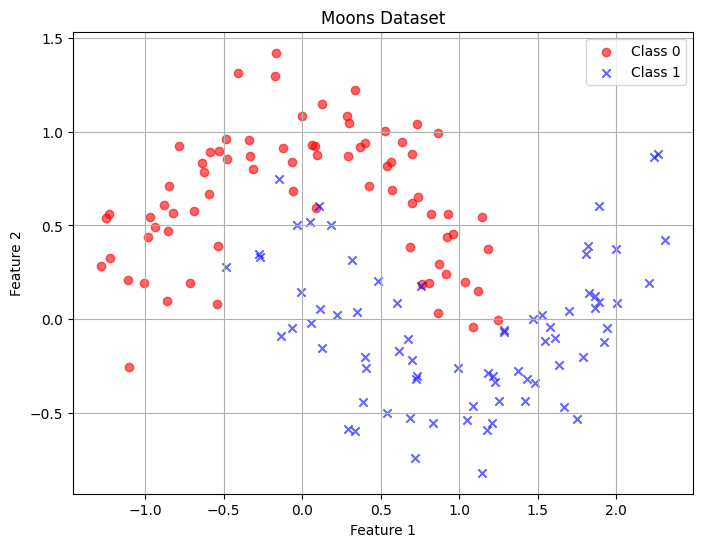

In [1]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

# Moons Trainings_Datensatz mit 150 Beispielen.
X, y = make_moons(n_samples=150, noise=0.2, random_state=42)

# Plot the Moons dataset
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0, 0], X[y == 0, 1], color='red', marker='o', label='Class 0', alpha=0.6)
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', marker='x', label='Class 1', alpha=0.6)
plt.title('Moons Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

# Entscheidungsbaum Modell initialisieren und zwei Varianten trainieren

In [2]:
from sklearn.tree import DecisionTreeClassifier

# Entscheidungsbaum 1 initialisieren,
# min_samples_leaf = 1 für minimale Anzahl Datenpunkte im Blatt (Default)
tree_clf1 = DecisionTreeClassifier(min_samples_leaf=1, random_state=42)
tree_clf1.fit(X, y)

# Entscheidungsbaum 2, Beispiel für Regularisierung
# Jedes Blatt muss mindestens 5 Datenpunkte haben.
tree_clf2 = DecisionTreeClassifier(min_samples_leaf=5, random_state=42)
tree_clf2.fit(X, y)



DecisionTreeClassifier(min_samples_leaf=5, random_state=42)

# Entscheidungsgrenzen der Bäume visualisieren

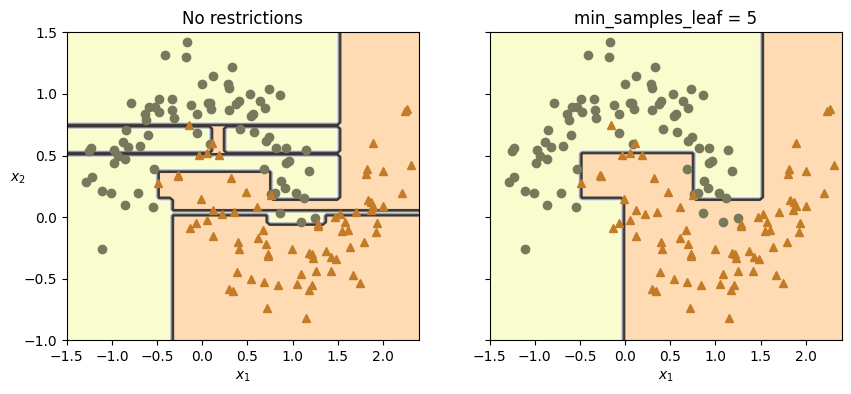

In [3]:
import numpy as np

def plot_decision_boundary(clf, X, y, axes, cmap):
    x1, x2 = np.meshgrid(np.linspace(axes[0], axes[1], 100),
                         np.linspace(axes[2], axes[3], 100))
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)

    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=cmap)
    plt.contour(x1, x2, y_pred, cmap="Greys", alpha=0.8)
    colors = {"Wistia": ["#78785c", "#c47b27"], "Pastel1": ["red", "blue"]}
    markers = ("o", "^")
    for idx in (0, 1):
        plt.plot(X[:, 0][y == idx], X[:, 1][y == idx],
                 color=colors[cmap][idx], marker=markers[idx], linestyle="none")
    plt.axis(axes)
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$", rotation=0)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)
plt.sca(axes[0])
plot_decision_boundary(tree_clf1, X, y,
                       axes=[-1.5, 2.4, -1, 1.5], cmap="Wistia")
plt.title("No restrictions")
plt.sca(axes[1])
plot_decision_boundary(tree_clf2, X, y,
                       axes=[-1.5, 2.4, -1, 1.5], cmap="Wistia")
plt.title(f"min_samples_leaf = {tree_clf2.min_samples_leaf}")
plt.ylabel("")
plt.show()

# Evaluiere beide Bäume mit Testdaten

In [4]:
X_test, y_test = make_moons(
    n_samples=100,
    noise=0.2,
    random_state=42
    )

score1 = tree_clf1.score(X_test, y_test)
score2 = tree_clf2.score(X_test, y_test)

print(f"Genauigkeit für Entscheidungsbaum 1 (ohne Regularisierung): {score1:.2f}")
print(f"Genauigkeit für Entscheidungsbaum 2 (mit min_samples_leaf={tree_clf2.min_samples_leaf}): {score2:.2f}")

# Der zweite, regulierte Baum hat eine höhere Test-Genauigkeit.
# Wie erwartet reduziert die Regulariserung das Over-Fitting

Genauigkeit für Entscheidungsbaum 1 (ohne Regularisierung): 0.87
Genauigkeit für Entscheidungsbaum 2 (mit min_samples_leaf=5): 0.92
